## 03 · Time-Based Feature Engineering

**Goals**
1. Run the full feature-engineering pipeline.
2. Inspect calendar features (Year, Month, Week, Quarter, DayOfYear).
3. Visualise lag features — how well does last week predict this week?
4. Visualise rolling averages that smooth out noise.
5. Compute and plot a feature correlation heatmap.
6. Identify the most correlated features with `Weekly_Sales`.

---
Feature engineering is centralised in `src/preprocessing.py`.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from src.data_loader   import load_raw_data, merge_datasets
from src.preprocessing import full_pipeline, time_based_split
from src.config        import MODEL_FEATURES, PRIMARY_COLOR, SECONDARY_COLOR

plt.rcParams["figure.dpi"] = 110
print("Imports OK")

Imports OK


---
## 1 · Run the Full Pipeline

In [2]:
train_df, features_df, stores_df = load_raw_data()
df_raw = merge_datasets(train_df, features_df, stores_df)

print("\nRunning full feature-engineering pipeline...")
df = full_pipeline(df_raw)

print(f"\nNew columns added:")
new_cols = [c for c in df.columns if c not in df_raw.columns]
for c in new_cols:
    print(f"  {c}")

train_df    : 421,570 rows × 5 cols
features_df :   8,190 rows × 12 cols
stores_df   :      45 rows × 3 cols
Dropped MarkDown columns (>50% missing): ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
Merged shape : 421,570 rows × 11 cols
Date range   : 2010-02-05 → 2012-10-26

Running full feature-engineering pipeline...
Step 1/6 — Fill missing externals
Step 2/6 — Time features
Step 3/6 — Holiday flags
Step 4/6 — Store type encoding
Step 5/6 — Lag features
  Sales_Lag_1
  Sales_Lag_4
  Sales_Lag_8
  Sales_Lag_52
Step 6/6 — Rolling statistics
  Sales_MA_4, Sales_STD_4
  Sales_MA_8, Sales_STD_8
  Sales_MA_12, Sales_STD_12

Pipeline complete. Shape: 421,570 rows × 32 cols

New columns added:
  Year
  Month
  Week
  Quarter
  DayOfYear
  IsBlackFriday
  IsChristmas
  IsThanksgiving
  Type_A
  Type_B
  Type_C
  Sales_Lag_1
  Sales_Lag_4
  Sales_Lag_8
  Sales_Lag_52
  Sales_MA_4
  Sales_STD_4
  Sales_MA_8
  Sales_STD_8
  Sales_MA_12
  Sales_STD_12


---
## 2 · Calendar Features

In [4]:
cal_cols = ["Year", "Month", "Week", "Quarter", "DayOfYear"]
display(df[cal_cols].describe().T)

# Year breakdown
print("\nRecords per year:")
print(df["Year"].value_counts().sort_index().to_string())

,count,mean,std,min,25%,50%,75%,max
Year,421570.0,2010.968591,0.796876,2010.0,2010.0,2011.0,2012.0,2012.0
Month,421570.0,6.449510,3.243217,1.0,4.0,6.0,9.0,12.0
Week,421570.0,25.826762,14.151887,1.0,14.0,26.0,38.0,52.0
Quarter,421570.0,2.482767,1.071341,1.0,2.0,2.0,3.0,4.0
DayOfYear,421570.0,180.818742,99.211172,6.0,97.0,181.0,265.0,365.0



Records per year:
Year
2010    140679
2011    153453
2012    127438


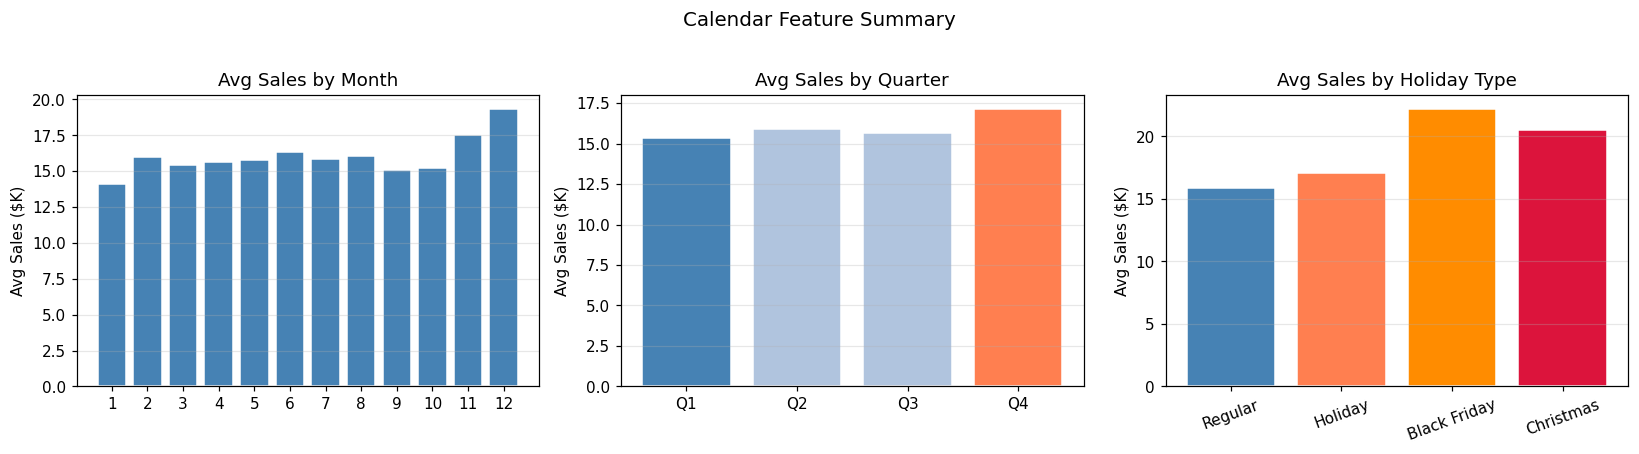

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sales by Month
monthly = df.groupby("Month")["Weekly_Sales"].mean()
axes[0].bar(monthly.index, monthly / 1e3, color=PRIMARY_COLOR, edgecolor="white")
axes[0].set_xticks(range(1, 13))
axes[0].set_title("Avg Sales by Month", fontsize=12)
axes[0].set_ylabel("Avg Sales ($K)", fontsize=10)
axes[0].grid(axis="y", alpha=0.3)

# Sales by Quarter
quarterly = df.groupby("Quarter")["Weekly_Sales"].mean()
axes[1].bar(["Q1","Q2","Q3","Q4"], quarterly / 1e3,
            color=[PRIMARY_COLOR, "lightsteelblue", "lightsteelblue", SECONDARY_COLOR],
            edgecolor="white")
axes[1].set_title("Avg Sales by Quarter", fontsize=12)
axes[1].set_ylabel("Avg Sales ($K)", fontsize=10)
axes[1].grid(axis="y", alpha=0.3)

# Holiday flag breakdown
hol_data = {
    "Regular": df[df["IsHoliday"] == 0]["Weekly_Sales"].mean(),
    "Holiday": df[df["IsHoliday"] == 1]["Weekly_Sales"].mean(),
    "Black Friday": df[df["IsBlackFriday"] == 1]["Weekly_Sales"].mean(),
    "Christmas": df[df["IsChristmas"] == 1]["Weekly_Sales"].mean(),
}
axes[2].bar(hol_data.keys(), [v / 1e3 for v in hol_data.values()],
            color=[PRIMARY_COLOR, SECONDARY_COLOR, "darkorange", "crimson"],
            edgecolor="white")
axes[2].set_title("Avg Sales by Holiday Type", fontsize=12)
axes[2].set_ylabel("Avg Sales ($K)", fontsize=10)
axes[2].grid(axis="y", alpha=0.3)
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=20)

plt.suptitle("Calendar Feature Summary", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 3 · Lag Features

In [13]:
lag_cols = ["Sales_Lag_1", "Sales_Lag_4", "Sales_Lag_8", "Sales_Lag_52"]
df_lag   = df.dropna(subset=lag_cols)
print(f"Rows with all lags available: {len(df_lag):,} (out of {len(df):,})")

lag_corr = df_lag[["Weekly_Sales"] + lag_cols].corr()["Weekly_Sales"].drop("Weekly_Sales")
print("\nCorrelation with Weekly_Sales:")
print(lag_corr.to_string())

Rows with all lags available: 261,083 (out of 421,570)

Correlation with Weekly_Sales:
Sales_Lag_1     0.959973
Sales_Lag_4     0.947284
Sales_Lag_8     0.916650
Sales_Lag_52    0.980920


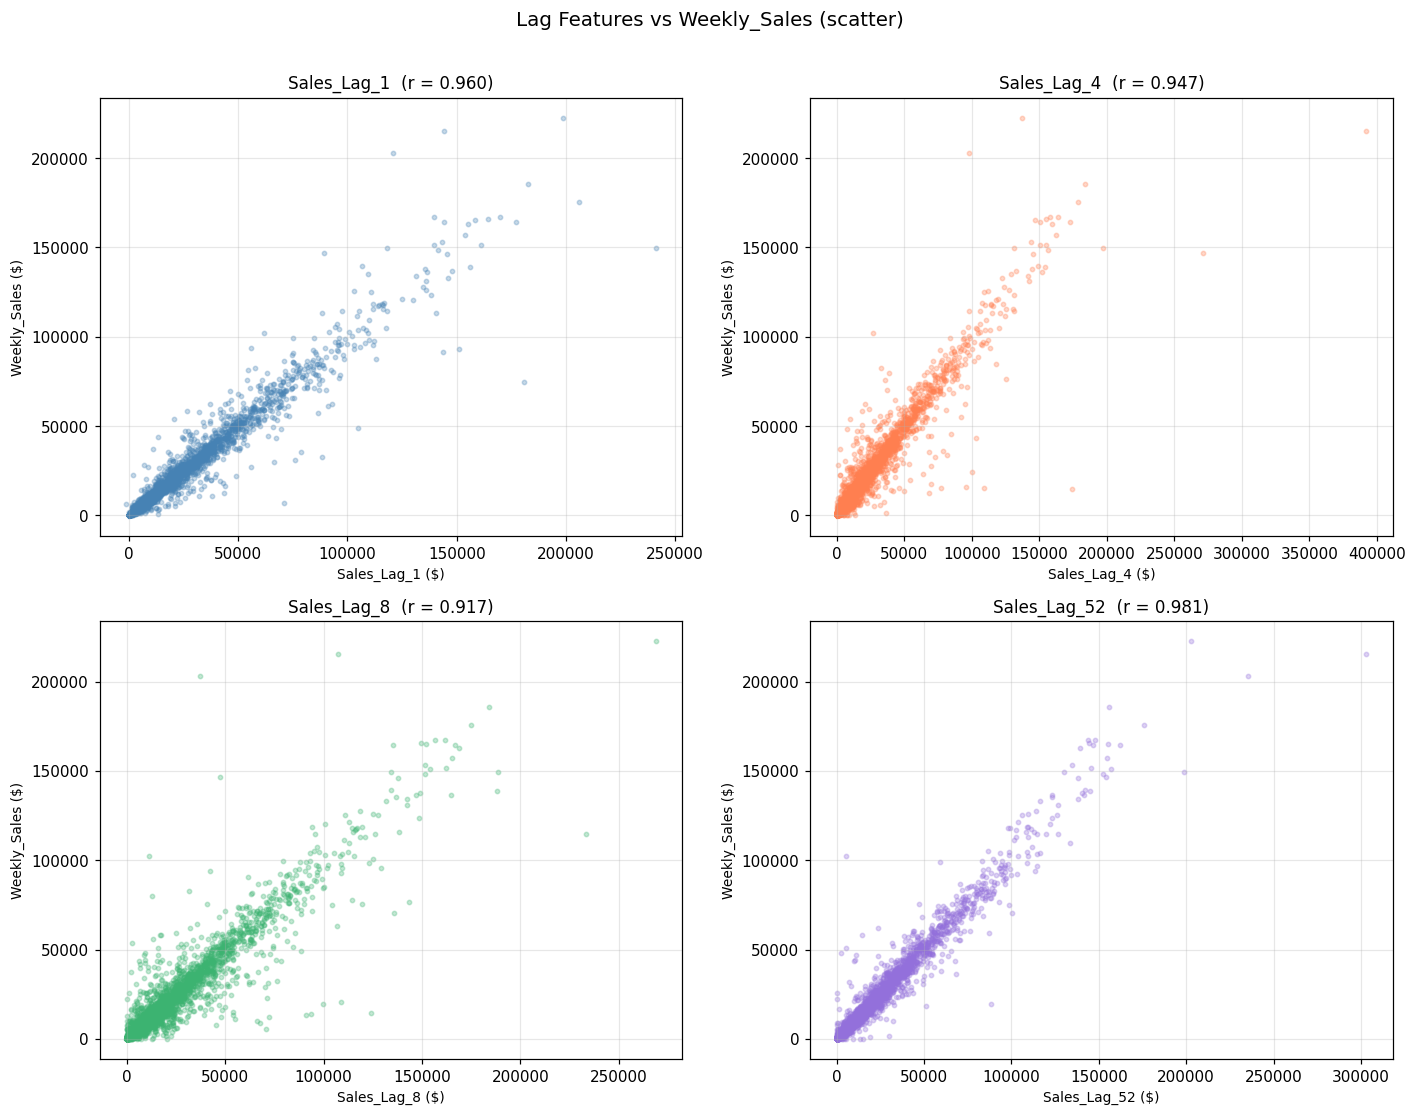

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
colors = [PRIMARY_COLOR, SECONDARY_COLOR, "mediumseagreen", "mediumpurple"]

for ax, lag_col, color in zip(axes.flatten(), lag_cols, colors):
    sample = df_lag.sample(min(5000, len(df_lag)), random_state=42)
    ax.scatter(sample[lag_col], sample["Weekly_Sales"],
               alpha=0.3, s=8, color=color)
    corr = df_lag["Weekly_Sales"].corr(df_lag[lag_col])
    ax.set_title(f"{lag_col}  (r = {corr:.3f})", fontsize=11)
    ax.set_xlabel(f"{lag_col} ($)", fontsize=9)
    ax.set_ylabel("Weekly_Sales ($)", fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Lag Features vs Weekly_Sales (scatter)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 4 · Rolling Averages

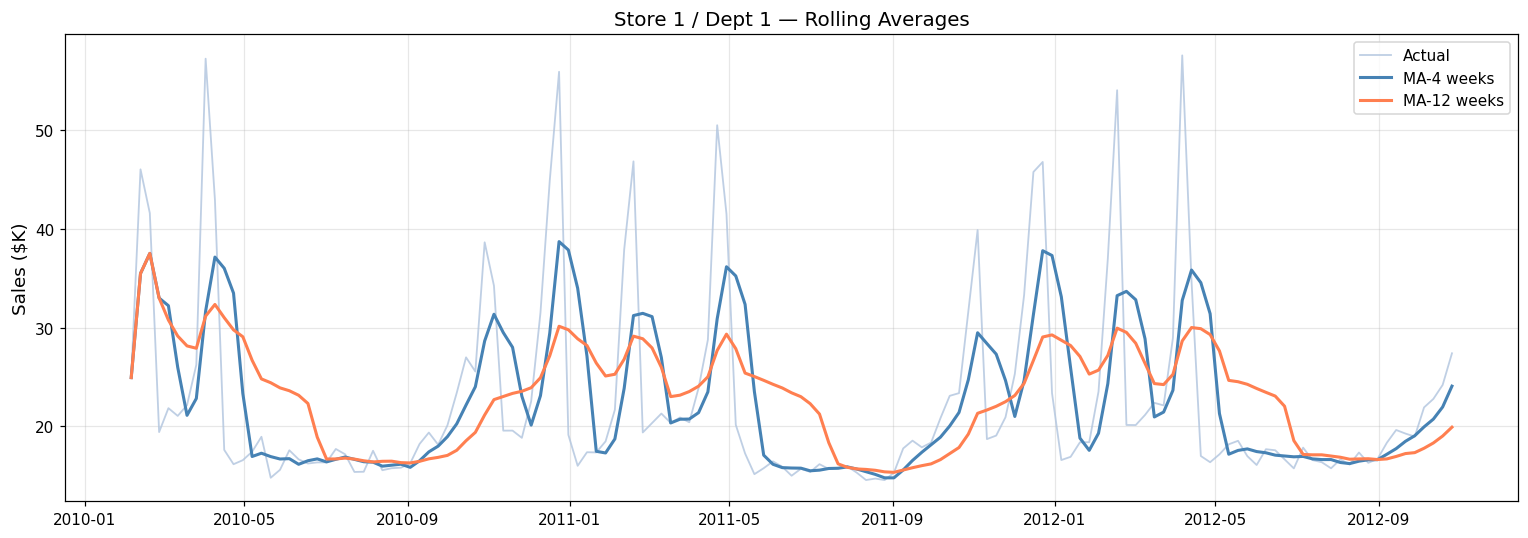

In [8]:
# Show rolling features for a single store-department as a time series
sample_store = 1
sample_dept  = 1
sub = df[(df["Store"] == sample_store) & (df["Dept"] == sample_dept)].copy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sub["Date"], sub["Weekly_Sales"] / 1e3,
        color="lightsteelblue", linewidth=1.2, alpha=0.8, label="Actual")
ax.plot(sub["Date"], sub["Sales_MA_4"]  / 1e3,
        color=PRIMARY_COLOR, linewidth=2, label="MA-4 weeks")
ax.plot(sub["Date"], sub["Sales_MA_12"] / 1e3,
        color=SECONDARY_COLOR, linewidth=2, label="MA-12 weeks")
ax.set_title(f"Store {sample_store} / Dept {sample_dept} — Rolling Averages", fontsize=13)
ax.set_ylabel("Sales ($K)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5 · Feature Correlation Heatmap

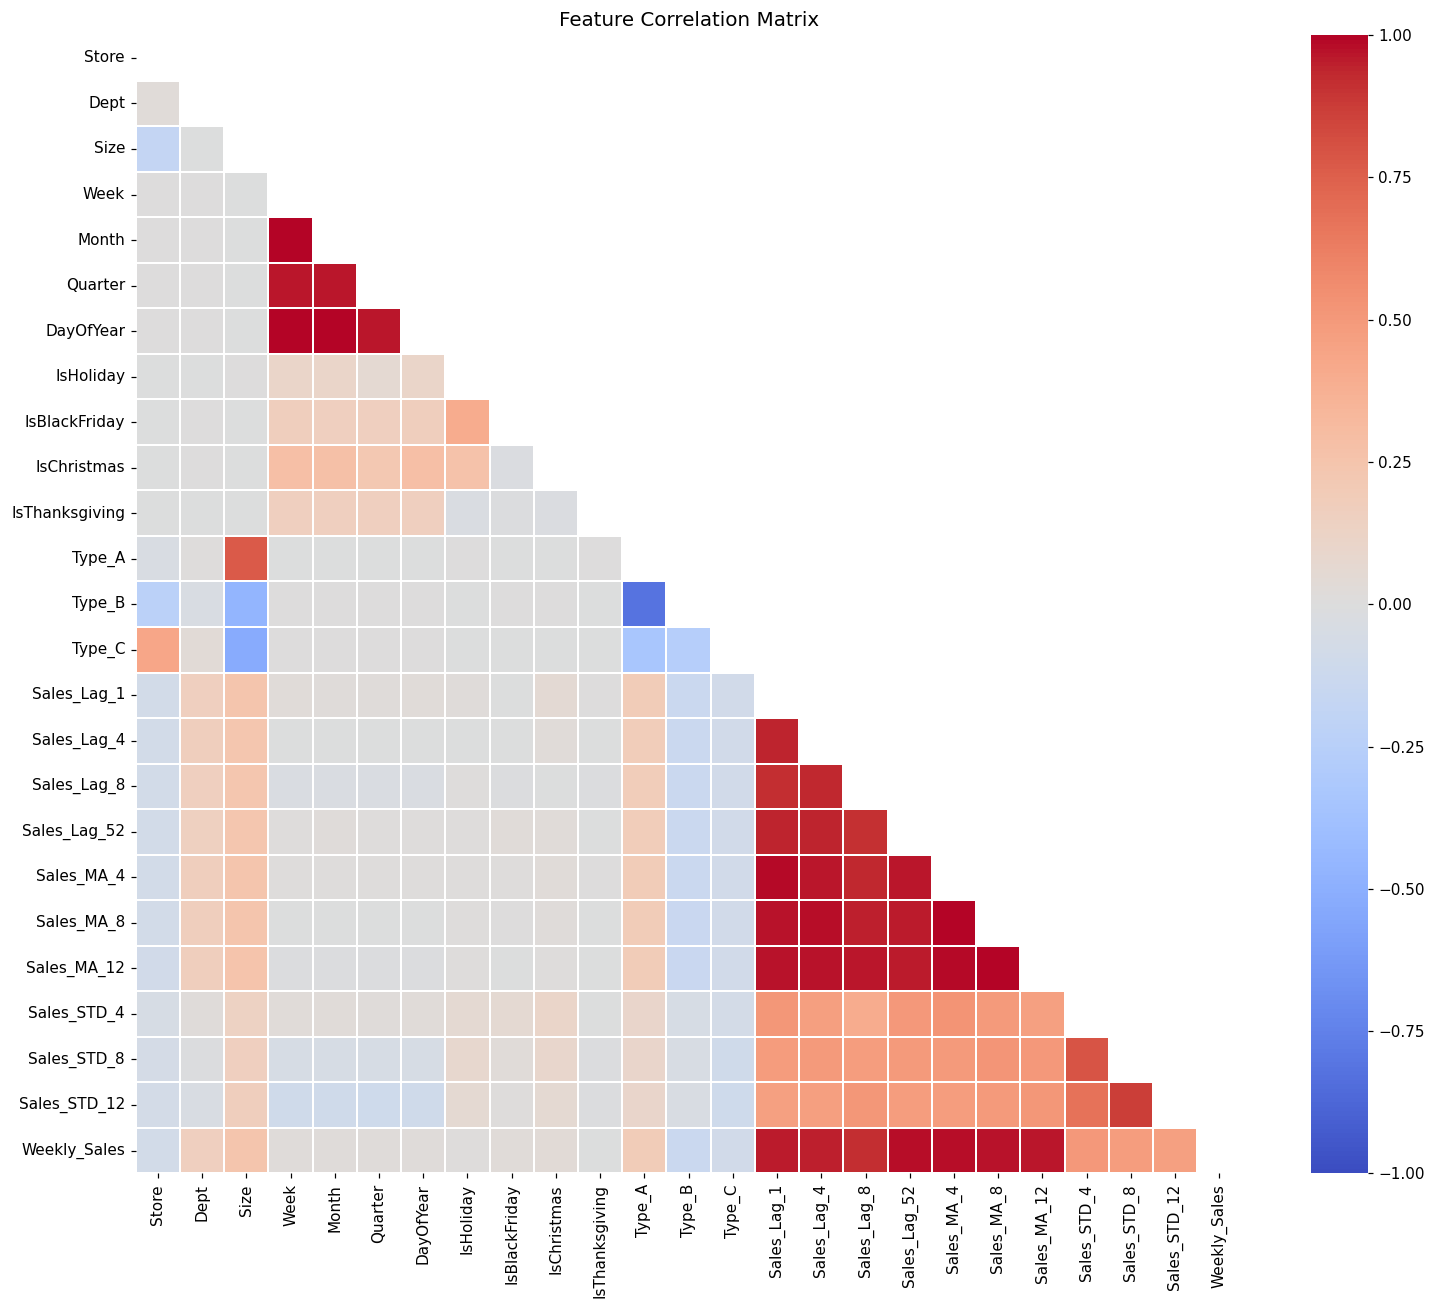

In [9]:
corr_cols = MODEL_FEATURES + ["Weekly_Sales"]
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=False, cmap="coolwarm",
    center=0, linewidths=0.3, ax=ax, vmin=-1, vmax=1
)
ax.set_title("Feature Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.show()

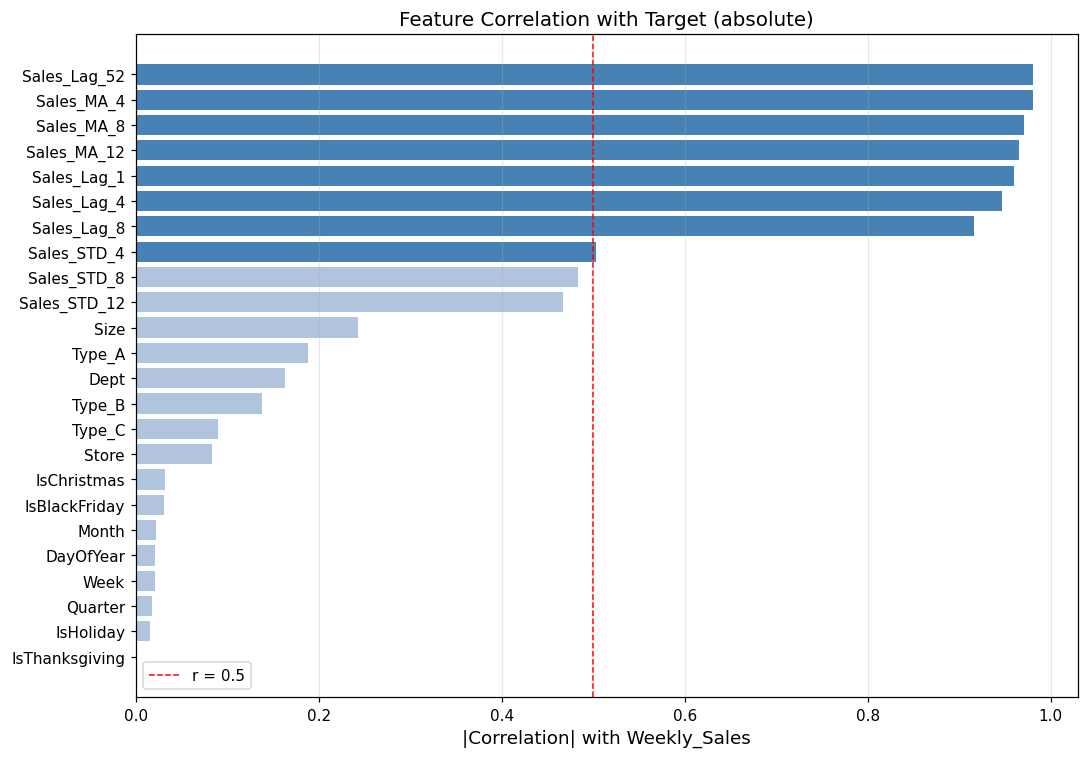


Top 10 features by |correlation| with Weekly_Sales:
Sales_Lag_52    0.980920
Sales_MA_4      0.980333
Sales_MA_8      0.971397
Sales_MA_12     0.965794
Sales_Lag_1     0.959973
Sales_Lag_4     0.947284
Sales_Lag_8     0.916650
Sales_STD_4     0.503661
Sales_STD_8     0.483765
Sales_STD_12    0.466543


In [10]:
target_corr = (
    df[corr_cols].dropna()
    .corr()["Weekly_Sales"]
    .drop("Weekly_Sales")
    .abs()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [PRIMARY_COLOR if v > 0.5 else "lightsteelblue" for v in target_corr.values]
ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=colors[::-1])
ax.axvline(0.5, color="red", linestyle="--", linewidth=1, label="r = 0.5")
ax.set_xlabel("|Correlation| with Weekly_Sales", fontsize=12)
ax.set_title("Feature Correlation with Target (absolute)", fontsize=13)
ax.legend()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 features by |correlation| with Weekly_Sales:")
print(target_corr.head(10).to_string())

---
## 6 · Final Feature Set Overview

In [11]:
X_train, X_val, X_test, y_train, y_val, y_test = time_based_split(df)

print(f"\nFeature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val  : {X_val.shape}")
print(f"  X_test : {X_test.shape}")
print(f"\nFeatures ({len(X_train.columns)}):")
for i, col in enumerate(X_train.columns, 1):
    print(f"  {i:>2}. {col}")

Train : 197,201 samples  2011-02-04 – 2012-05-25
Val   :  26,017 samples  2012-06-01 – 2012-07-27
Test  :  37,865 samples  2012-08-03 – 2012-10-26

Feature matrix shapes:
  X_train: (197201, 24)
  X_val  : (26017, 24)
  X_test : (37865, 24)

Features (24):
   1. Store
   2. Dept
   3. Size
   4. Week
   5. Month
   6. Quarter
   7. DayOfYear
   8. IsHoliday
   9. IsBlackFriday
  10. IsChristmas
  11. IsThanksgiving
  12. Type_A
  13. Type_B
  14. Type_C
  15. Sales_Lag_1
  16. Sales_Lag_4
  17. Sales_Lag_8
  18. Sales_Lag_52
  19. Sales_MA_4
  20. Sales_MA_8
  21. Sales_MA_12
  22. Sales_STD_4
  23. Sales_STD_8
  24. Sales_STD_12


---
## Summary

### Feature Groups

| Feature group | Features | Key result |
|---------------|----------|------------|
| Calendar | Year, Month, Week, Quarter, DayOfYear | Q4 (weeks 47–52) shows the sharpest spike |
| Holiday flags | IsHoliday, IsBlackFriday, IsChristmas, IsThanksgiving | Black Friday and Christmas both lift average sales significantly |
| Store identity | Store, Dept, Size, Type_A / B / C | Dept + Store together encode most of the inter-series variance |
| Lag features | Sales_Lag_1 / 4 / 8 / 52 | **Lag_52 highest: r = 0.981** — strong year-over-year patterns |
| Rolling statistics | Sales_MA / STD at 4, 8, 12 weeks | MA features correlate > 0.94 with target; STD captures volatility |

### Lag Feature Correlations with Weekly_Sales

| Lag | Correlation | Interpretation |
|-----|-------------|----------------|
| `Sales_Lag_52` | **0.981** | Same week last year — strongest single feature |
| `Sales_Lag_1` | 0.960 | Last week — very strong short-term autocorrelation |
| `Sales_Lag_4` | 0.947 | One month ago |
| `Sales_Lag_8` | 0.917 | Two months ago — still strong |

### Data Size After Pipeline

| Stage | Rows |
|-------|------|
| After merge | 421,570 |
| After lag-52 requirement (NaN dropped) | 261,083 |
| **Final model split — Train** | **197,201** |
| Final model split — Val | 26,017 |
| Final model split — Test | 37,865 |

> **160,487 rows dropped** because the lag-52 feature requires a full year of prior history.
> This is expected — Notebook 02 already flagged this as the model split.

**Next**: `04_prophet_baseline.ipynb` — train a Prophet time-series model on aggregated weekly sales.